In [17]:
import os
import numpy as np
import json
import torch
import matplotlib.pyplot as plt

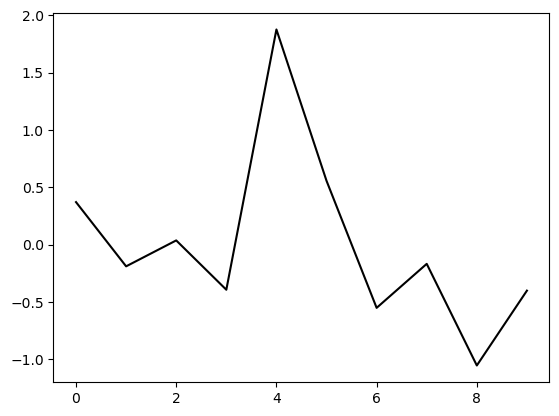

In [27]:
from noise_scheduler import DiffusionScheduler
device = torch.device("cpu")
diff_scheduler = DiffusionScheduler(device, T=400)
decoder_target = np.load('../../outputs/Diffusion/non_pretrained_base_model/batch_0/decoder_target.npy')
decoder_target = torch.tensor(decoder_target[0])
t=399
noise = torch.randn_like(decoder_target, device=device)
noisy_decoder_target = diff_scheduler.add_noise(decoder_target, t, noise)
plot_vals = noisy_decoder_target[0, :, 2]
plt.plot(range(len(plot_vals)), plot_vals, color="black")
plt.show()

In [10]:
def get_full_evaluation_metrics(outputs_path):
    vitals = ['HR', 'RESP', 'SpO2']
    
    full_metric_dict = {}
    for vital in vitals:
        full_metric_dict[vital] = {
            'crpss': [],
            'maes': []
        }
    for batch_folder in os.listdir(outputs_path):
        metric_path = f'{outputs_path}/{batch_folder}/metrics.json'
        with open(metric_path, 'r') as f:
            metrics_dict = json.load(f)

        for vital in vitals:
            vital_dict = metrics_dict[vital]
            crps = vital_dict['crpss']
            mae = vital_dict['maes']

            full_metric_dict[vital]['maes'].extend(mae)
            full_metric_dict[vital]['crpss'].extend(crps)

    for vital in vitals:
        print(f'{vital} Mean MAE: {np.mean(full_metric_dict[vital]["maes"])}')
        print(f'{vital} Mean CRPS: {np.mean(full_metric_dict[vital]["crpss"])}')

# Base Model (pretrained vs non pretrained)

## Non Pretrained

In [11]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.3807327182798845
HR Mean CRPS: 1.9642922160447258
RESP Mean MAE: 1.9467196261987347
RESP Mean CRPS: 1.555248239707393
SpO2 Mean MAE: 0.9067824135259226
SpO2 Mean CRPS: 0.7229422461281397


## Pretrained

In [12]:
#testing variables
use_pretrained_vital_encoder_weights = True # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.0421840558222843
HR Mean CRPS: 1.6625521694943324
RESP Mean MAE: 1.9440217497897987
RESP Mean CRPS: 1.569736127240378
SpO2 Mean MAE: 0.9163051405925173
SpO2 Mean CRPS: 0.7294810663265953


# Waveform Data (waveform conditioned vs non waveform conditioned)

## Non waveform Conditioned

In [13]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = True # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.234619962536004
HR Mean CRPS: 1.84081787888523
RESP Mean MAE: 2.0068510677313003
RESP Mean CRPS: 1.637515498493608
SpO2 Mean MAE: 1.1054630147908115
SpO2 Mean CRPS: 0.9092146756082562


## Waveform Conditioned

In [14]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = True # CHANGE
waveform_conditioning = True # CHANGE

use_clinical_data = False  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.265982556142111
HR Mean CRPS: 1.8272523442665953
RESP Mean MAE: 1.9838680006355405
RESP Mean CRPS: 1.6109636249048893
SpO2 Mean MAE: 1.0283098770870975
SpO2 Mean CRPS: 0.8523177263101565


# Clinical Data (clinical conditioned vs non clinical condtioned)

## Non Clinical Conditioned

In [15]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = True  # CHANGE
clinical_conditioning = False  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.597001531080847
HR Mean CRPS: 2.0920708209482837
RESP Mean MAE: 2.069739731243585
RESP Mean CRPS: 1.667336803320014
SpO2 Mean MAE: 1.157007907722991
SpO2 Mean CRPS: 0.9333637645033795


## Clinical Conditioned

In [16]:
#testing variables
use_pretrained_vital_encoder_weights = False # CHANGE

use_waveform_data = False # CHANGE
waveform_conditioning = False # CHANGE

use_clinical_data = True  # CHANGE
clinical_conditioning = True  # CHANGE

modifier = ""
if use_waveform_data:
  modifier += "/waveform_data"
  if waveform_conditioning:
    modifier += "/waveform_conditioned"
  else:
    modifier += "/non_waveform_conditioned"
if use_clinical_data:
  modifier += "/clinical_data"
  if clinical_conditioning:
    modifier += "/clinical_conditioned"
  else:
    modifier += "/non_clinical_conditioned"
  
if use_pretrained_vital_encoder_weights:
  modifier += "/forecasing_with_pretrained_vital_encoders"

outputs_path = f'../../outputs/Diffusion{modifier}'
if modifier == "":
  outputs_path += "/non_pretrained_base_model"

get_full_evaluation_metrics(outputs_path)

HR Mean MAE: 2.3961569723187224
HR Mean CRPS: 1.9352413609136145
RESP Mean MAE: 2.0261814228344686
RESP Mean CRPS: 1.6332251616372582
SpO2 Mean MAE: 1.11782411506026
SpO2 Mean CRPS: 0.9093699327370965
